# Naive Bayes

## What is Naive Bayes?
A family of probabilistic classifiers based on **Bayes' theorem** with the **naive assumption** that features are conditionally independent given the class.

Despite being "naive", it works surprisingly well for text classification and real-time prediction.

---

## 1. Bayes' Theorem

$$P(y|x) = \frac{P(x|y) \cdot P(y)}{P(x)}$$

- $P(y|x)$: **Posterior** probability of class $y$ given features $x$
- $P(x|y)$: **Likelihood** probability of features given class
- $P(y)$: **Prior** probability of class
- $P(x)$: **Evidence** normalizing constant

---

## 2. Naive Bayes Classifier

**Naive assumption**: features are conditionally independent:

$$P(x_1, x_2, \ldots, x_n | y) = \prod_{i=1}^{n} P(x_i | y)$$

Classification rule (MAP):

$$\hat{y} = \arg\max_y P(y) \prod_{i=1}^{n} P(x_i|y)$$

In log space (for numerical stability):

$$\hat{y} = \arg\max_y \left[\log P(y) + \sum_{i=1}^{n} \log P(x_i|y)\right]$$

---

## 3. Types of Naive Bayes

### Gaussian Naive Bayes
Features are continuous, assumed normally distributed:

$$P(x_i|y) = \frac{1}{\sqrt{2\pi\sigma_{y,i}^2}} \exp\left(-\frac{(x_i - \mu_{y,i})^2}{2\sigma_{y,i}^2}\right)$$

### Multinomial Naive Bayes
For discrete count data (e.g., word counts in text):

$$P(x_i|y) = \frac{N_{y,x_i} + \alpha}{N_y + \alpha n}$$

Where $\alpha$ is the **Laplace smoothing** parameter.

### Bernoulli Naive Bayes
For binary/boolean features:

$$P(x_i|y) = P(i|y)^{x_i}(1-P(i|y))^{1-x_i}$$

### Complement Naive Bayes
Better for imbalanced text datasets. Train using complement of each class:

$$\hat{y} = \arg\min_y \sum_i \log\frac{N_{\bar{y},i} + \alpha}{N_{\bar{y}} + \alpha n}$$

### Categorical Naive Bayes
For categorical features where each feature $i$ can take $K_i$ values.

---

## 4. Laplace Smoothing

Prevents zero probability for unseen features:

$$P(x_i|y) = \frac{\text{count}(x_i, y) + \alpha}{\text{count}(y) + \alpha \cdot |V|}$$

Where $|V|$ = vocabulary size, $\alpha=1$ means Laplace, $\alpha<1$ means Lidstone smoothing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_20newsgroups
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
np.random.seed(42)

## Gaussian Naive Bayes from Scratch

In [2]:
class GaussianNBScratch:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = {}
        self.means = {}
        self.vars = {}
        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = len(X_c) / len(y)
            self.means[c] = X_c.mean(axis=0)
            self.vars[c] = X_c.var(axis=0) + 1e-9
        return self

    def _gaussian_log_pdf(self, x, mean, var):
        return -0.5 * np.sum(np.log(2 * np.pi * var) + (x - mean)**2 / var)

    def predict(self, X):
        preds = []
        for x in X:
            posteriors = {}
            for c in self.classes:
                log_prior = np.log(self.priors[c])
                log_likelihood = self._gaussian_log_pdf(x, self.means[c], self.vars[c])
                posteriors[c] = log_prior + log_likelihood
            preds.append(max(posteriors, key=posteriors.get))
        return np.array(preds)


X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gnb_scratch = GaussianNBScratch().fit(X_train, y_train)
gnb_sk = GaussianNB().fit(X_train, y_train)

print(f'Scratch GNB Accuracy: {accuracy_score(y_test, gnb_scratch.predict(X_test)):.4f}')
print(f'Sklearn GNB Accuracy: {gnb_sk.score(X_test, y_test):.4f}')

Scratch GNB Accuracy: 1.0000
Sklearn GNB Accuracy: 1.0000


## Gaussian Naive Bayes Decision Boundary

Visualizing the decision boundary helps understand what regions GaussianNB assigns to each class. Because it models each feature with an independent Gaussian per class, the boundaries are typically smooth quadratic curves.

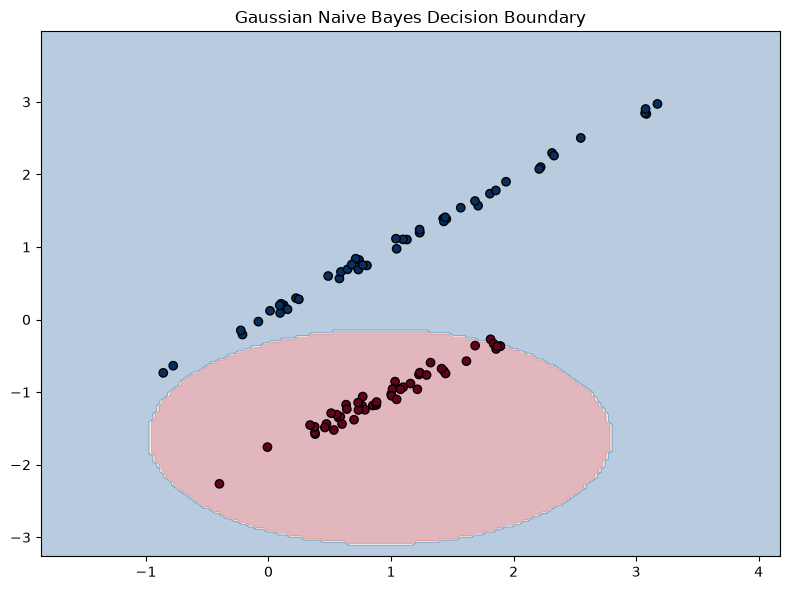

In [3]:
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import numpy as np
X2d, y2d = make_classification(n_features=2, n_redundant=0, n_informative=2, 
                                 n_clusters_per_class=1, random_state=42)
gnb2d = GaussianNB()
gnb2d.fit(X2d, y2d)
xx, yy = np.meshgrid(np.linspace(X2d[:,0].min()-1, X2d[:,0].max()+1, 200),
                      np.linspace(X2d[:,1].min()-1, X2d[:,1].max()+1, 200))
Z = gnb2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X2d[:,0], X2d[:,1], c=y2d, cmap='RdBu', edgecolors='k')
plt.title('Gaussian Naive Bayes Decision Boundary')
plt.tight_layout()
plt.show()

## Text Classification with Multinomial & Complement NB

In [4]:
categories = ['sci.space', 'comp.graphics', 'talk.politics.guns', 'rec.sport.hockey']
newsgroups = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_tr = vectorizer.fit_transform(newsgroups.data)
X_te = vectorizer.transform(newsgroups_test.data)
y_tr = newsgroups.target
y_te = newsgroups_test.target

models = {
    'MultinomialNB': MultinomialNB(alpha=0.1),
    'ComplementNB': ComplementNB(alpha=0.1),
    'BernoulliNB': BernoulliNB(alpha=0.1)
}

for name, model in models.items():
    model.fit(X_tr, y_tr)
    acc = model.score(X_te, y_te)
    print(f'{name}: {acc:.4f}')

MultinomialNB: 0.9075
ComplementNB: 0.9049
BernoulliNB: 0.8060


## Multi-Class Metrics Explained

When dealing with more than two classes, averaging strategies matter:

- **macro avg**: average each class metric equally, fair when classes are equally important
- **weighted avg**: weight each class metric by its support (number of samples), fair when class sizes differ
- **micro avg**: aggregate TP/FP/FN across all classes then compute

In [5]:
from sklearn.metrics import classification_report
mnb = models['MultinomialNB']
print('--- Multinomial NB ---')
print(classification_report(y_te, mnb.predict(X_te)))

--- Multinomial NB ---
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       389
           1       0.89      0.95      0.92       399
           2       0.92      0.85      0.88       394
           3       0.90      0.91      0.90       364

    accuracy                           0.91      1546
   macro avg       0.91      0.91      0.91      1546
weighted avg       0.91      0.91      0.91      1546



## Categorical Naive Bayes

CategoricalNB is designed for nominal (unordered categorical) features. Using GaussianNB on nominal features would be wrong because it assumes a continuous normal distribution, which has no meaning for categories like color or shape. CategoricalNB instead models a categorical distribution per feature per class, so it captures the true likelihood of each category value correctly.

In [6]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
# Create a small categorical dataset
X_cat = np.array([['small','red','circle'],['large','blue','square'],
                   ['small','blue','circle'],['large','red','square'],
                   ['medium','red','circle'],['medium','blue','square']])
y_cat = np.array([0,1,0,1,0,1])
enc = OrdinalEncoder()
X_enc = enc.fit_transform(X_cat)
cnb = CategoricalNB()
cnb.fit(X_enc, y_cat)
test = enc.transform([['small','red','circle'],['large','blue','square']])
print('CategoricalNB predictions:', cnb.predict(test))

CategoricalNB predictions: [0 1]


## Additional Learning Resources

### Papers
- [A Comparison of Event Models for Naive Bayes Text Classification (McCallum & Nigam)](https://www.cs.cmu.edu/~knigam/papers/multinomial-aaaiws98.pdf)
- [Tackling the Poor Assumptions of Naive Bayes Text Classifiers (Rennie et al.)](https://people.csail.mit.edu/jrennie/papers/icml03-nb.pdf) Complement NB

### Videos
- [StatQuest: Naive Bayes](https://www.youtube.com/watch?v=O2L2Uv9pdDA)
- [StatQuest: Gaussian Naive Bayes](https://www.youtube.com/watch?v=H3EjCKtlVog)

### Documentation
- [Scikit-Learn Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html)